In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/stock_market_daily.csv", parse_dates=["date"])
df.shape

(6288, 29)

In [42]:
df.head()

,date,Technology,Financials,Healthcare,Energy,ConsumerDiscret,ConsumerStaples,Industrials,Materials,Utilities,...,DowJones_return,VIX_return,TBond10Y_return,year,month,weekday,crisis_dotcom,crisis_gfc,crisis_covid,crisis_rate_hike
0,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2000,1,0,0,0,0,0
1,2000-01-04,-0.056507,-0.047966,-0.036806,-0.009756,-0.046659,-0.024891,-0.016392,-0.030071,0.010591,...,-0.055544,-0.009621,0.115655,2000,1,1,0,0,0,0
2,2000-01-05,-0.005338,-0.009918,0.009793,0.002781,-0.007720,-0.011764,0.017486,0.029039,0.037025,...,-0.006190,0.017579,-0.022214,2000,1,2,0,0,0,0
3,2000-01-06,-0.040156,0.041497,0.022363,0.047487,-0.017424,0.019411,0.031641,0.027165,0.002855,...,-0.038790,-0.007577,-0.025748,2000,1,3,0,0,0,0
4,2000-01-07,0.034152,0.008738,0.063929,0.012612,0.035998,0.049830,0.023624,0.004960,0.010770,...,0.041718,-0.006871,-0.155849,2000,1,4,0,0,0,0


In [43]:
sectors = ["Financials", "Technology", "ConsumerStaples", "Utilities", "Energy"]

data = df[["date", "year", "crisis_gfc"] + sectors].dropna()
data = data.set_index("date")
data.sample(5)

,year,crisis_gfc,Financials,Technology,ConsumerStaples,Utilities,Energy
date,,,,,,,
2007-11-01,2007,1,-0.048867,-0.015812,-0.020755,-0.017904,-0.021696
2017-12-05,2017,0,-0.005083,-0.003916,-0.003500,-0.007035,0.000207
2002-01-08,2002,0,-0.014313,0.006541,0.003272,-0.011074,-0.008432
2006-11-13,2006,0,0.001116,0.014776,-0.004203,0.001771,0.000453
2012-07-06,2012,0,-0.011317,-0.016817,-0.001123,-0.003546,-0.009553


In [44]:
before = data.loc["2003-01-01":"2007-10-08"]
during = data.loc["2007-10-09":"2009-03-09"]
after  = data.loc["2009-03-10":"2010-12-31"]

In [45]:
cov_before = before[sectors].cov() * 252
cov_during = during[sectors].cov() * 252

print("Annualized covariance — BEFORE crisis:")
print(cov_before.round(4))
print("\nAnnualized covariance — DURING crisis:")
print(cov_during.round(4))

Annualized covariance — BEFORE crisis:
                 Financials  Technology  ConsumerStaples  Utilities  Energy
Financials           0.0242      0.0214           0.0113     0.0131  0.0128
Technology           0.0214      0.0492           0.0124     0.0123  0.0155
ConsumerStaples      0.0113      0.0124           0.0111     0.0076  0.0059
Utilities            0.0131      0.0123           0.0076     0.0194  0.0140
Energy               0.0128      0.0155           0.0059     0.0140  0.0498

Annualized covariance — DURING crisis:
                 Financials  Technology  ConsumerStaples  Utilities  Energy
Financials           0.5903      0.2342           0.1183     0.1268  0.2559
Technology           0.2342      0.1827           0.0761     0.0907  0.1801
ConsumerStaples      0.1183      0.0761           0.0597     0.0620  0.0913
Utilities            0.1268      0.0907           0.0620     0.0994  0.1324
Energy               0.2559      0.1801           0.0913     0.1324  0.3077


In [46]:
vol_before = np.sqrt(np.diag(cov_before))
vol_during = np.sqrt(np.diag(cov_during))

vol_compare = pd.DataFrame({
    "Before crisis": vol_before,
    "During crisis": vol_during,
}, index=sectors)
vol_compare["Change (x)"] = vol_compare["During crisis"] / vol_compare["Before crisis"]
vol_compare.round(3)

,Before crisis,During crisis,Change (x)
Financials,0.156,0.768,4.934
Technology,0.222,0.427,1.926
ConsumerStaples,0.105,0.244,2.322
Utilities,0.139,0.315,2.262
Energy,0.223,0.555,2.486


In [47]:
corr_before = before[sectors].corr()
corr_during = during[sectors].corr()
corr_after = after[sectors].corr()

def avg_offdiag(corr_df):
    n = len(corr_df)
    return (corr_df.values.sum() - n) / (n * n - n)

print(f"Average pairwise correlation — before crisis: {avg_offdiag(corr_before):.3f}")
print(f"Average pairwise correlation — during crisis:  {avg_offdiag(corr_during):.3f}")
print(f"Average pairwise correlation — after crisis:   {avg_offdiag(corr_after):.3f}")

Average pairwise correlation — before crisis: 0.474
Average pairwise correlation — during crisis:  0.687
Average pairwise correlation — after crisis:   0.615


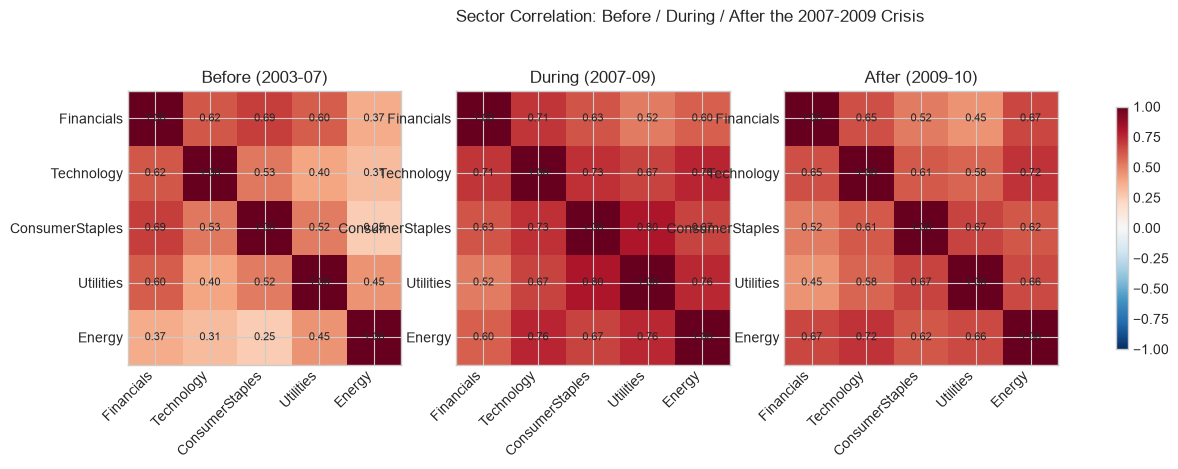

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, corr, title in zip(axes, [corr_before, corr_during, corr_after], ["Before (2003-07)", "During (2007-09)", "After (2009-10)"]):
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(sectors))); ax.set_xticklabels(sectors, rotation=45, ha="right")
    ax.set_yticks(range(len(sectors))); ax.set_yticklabels(sectors)
    ax.set_title(title)
    for i in range(len(sectors)):
        for j in range(len(sectors)):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.7)
plt.suptitle("Sector Correlation: Before / During / After the 2007-2009 Crisis")
plt.show()

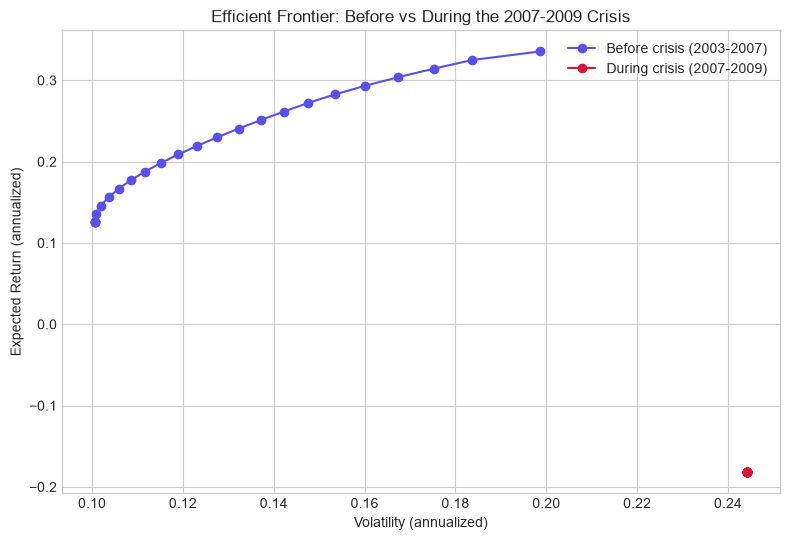

In [49]:
from pypfopt import EfficientFrontier

def get_frontier(returns_df, sectors, n_points=25):
    mu = returns_df[sectors].mean() * 252
    S = returns_df[sectors].cov() * 252

    rets, vols = [], []
    for target in np.linspace(mu.min(), mu.max(), n_points):
        try:
            ef = EfficientFrontier(mu, S)
            ef.efficient_return(target_return=target)
            r, v, _ = ef.portfolio_performance()
            rets.append(r)
            vols.append(v)
        except Exception:
            continue
    return np.array(vols), np.array(rets)

vols_before, rets_before = get_frontier(before, sectors)
vols_during, rets_during = get_frontier(during, sectors)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(vols_before, rets_before, "o-", color="#5B4FE9", label="Before crisis (2003-2007)")
ax.plot(vols_during, rets_during, "o-", color="crimson", label="During crisis (2007-2009)")
ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected Return (annualized)")
ax.set_title("Efficient Frontier: Before vs During the 2007-2009 Crisis")
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
mu_test = during[sectors].mean() * 252
S_test = during[sectors].cov() * 252
print(mu_test)
print()

from pypfopt import EfficientFrontier
ef = EfficientFrontier(mu_test, S_test)
try:
    ef.efficient_return(target_return=mu_test.mean())
    print(ef.portfolio_performance())
except Exception as e:
    print("ERROR:", e)

Financials        -0.687540
Technology        -0.423210
ConsumerStaples   -0.181733
Utilities         -0.210678
Energy            -0.293426
dtype: float64

(np.float64(-0.1817330066686969), np.float64(0.24426138535766412), np.float64(-0.7440103821674109))


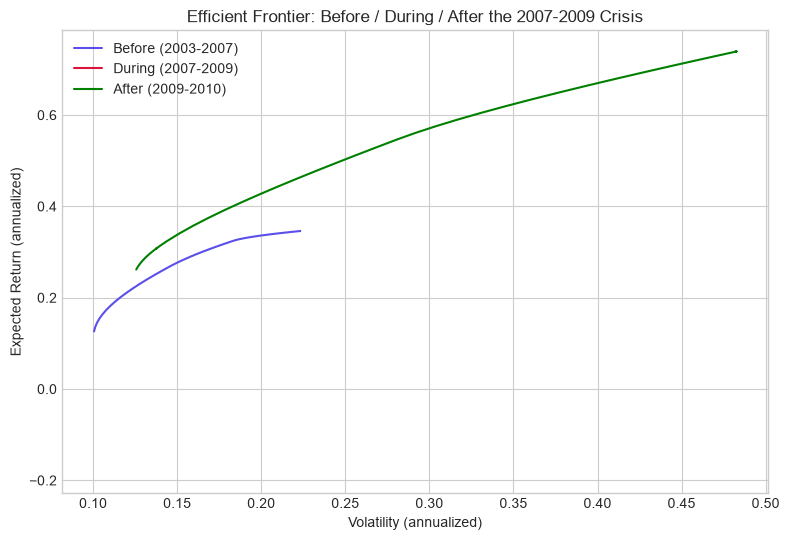

In [51]:
from pypfopt import CLA

def get_frontier_cla(returns_df, sectors):
    mu = returns_df[sectors].mean() * 252
    S = returns_df[sectors].cov() * 252
    cla = CLA(mu, S)
    cla.min_volatility()
    rets, vols, weights = cla.efficient_frontier()
    return np.array(vols), np.array(rets)

vols_before, rets_before = get_frontier_cla(before, sectors)
vols_during, rets_during = get_frontier_cla(during, sectors)
vols_after, rets_after = get_frontier_cla(after, sectors)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(vols_before, rets_before, "-", color="#5B4FE9", label="Before (2003-2007)")
ax.plot(vols_during, rets_during, "-", color="crimson", label="During (2007-2009)")
ax.plot(vols_after, rets_after, "-", color="green", label="After (2009-2010)")
ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected Return (annualized)")
ax.set_title("Efficient Frontier: Before / During / After the 2007-2009 Crisis")
ax.legend()
plt.tight_layout()
plt.show()

In [52]:
print("Before:", len(vols_before), "points")
print("During:", len(vols_during), "points")
print("After: ", len(vols_after), "points")

print("\nDuring vols:", vols_during)
print("During rets:", rets_during)

Before: 76 points
During: 50 points
After:  79 points

During vols: [0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139 0.24426139
 0.24426139 0.24426139]
During rets: [-0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301
 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301
 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301
 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301
 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.18173301 -0.181

In [53]:
from pypfopt import EfficientFrontier

def get_frontier_manual(returns_df, sectors, n_points=30, margin=0.05):
    mu = returns_df[sectors].mean() * 252
    S = returns_df[sectors].cov() * 252

    lo, hi = mu.min(), mu.max()
    span = hi - lo
    targets = np.linspace(lo + margin * span, hi - margin * span, n_points)

    rets, vols = [], []
    for target in targets:
        try:
            ef = EfficientFrontier(mu, S)
            ef.efficient_return(target_return=target)
            r, v, _ = ef.portfolio_performance()
            rets.append(r)
            vols.append(v)
        except Exception as e:
            pass 
    return np.array(vols), np.array(rets), len(targets)

vols_before, rets_before, n_before = get_frontier_manual(before, sectors)
vols_during, rets_during, n_during = get_frontier_manual(during, sectors)
vols_after, rets_after, n_after = get_frontier_manual(after, sectors)

print(f"Before: {len(vols_before)}/{n_before} succeeded")
print(f"During: {len(vols_during)}/{n_during} succeeded")
print(f"After:  {len(vols_after)}/{n_after} succeeded")

Before: 30/30 succeeded
During: 30/30 succeeded
After:  30/30 succeeded


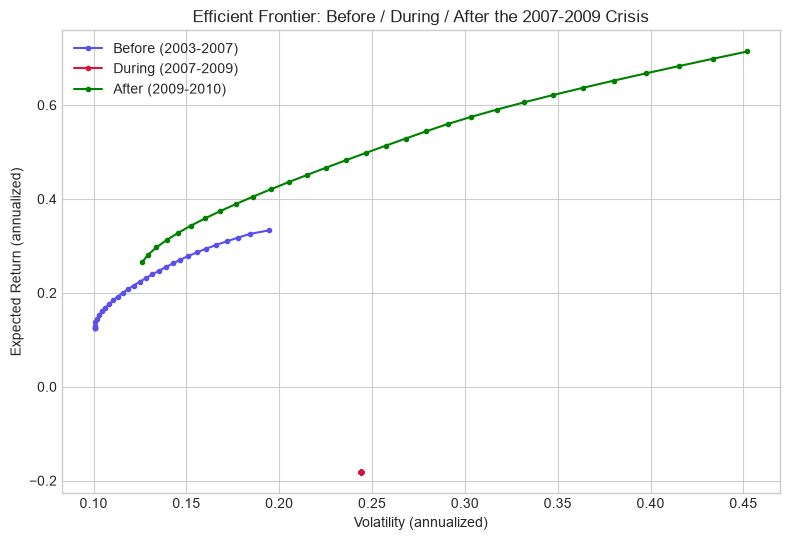

In [54]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(vols_before, rets_before, "o-", color="#5B4FE9", markersize=3, label="Before (2003-2007)")
ax.plot(vols_during, rets_during, "o-", color="crimson", markersize=3, label="During (2007-2009)")
ax.plot(vols_after, rets_after, "o-", color="green", markersize=3, label="After (2009-2010)")
ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected Return (annualized)")
ax.set_title("Efficient Frontier: Before / During / After the 2007-2009 Crisis")
ax.legend()
plt.tight_layout()
plt.show()

In [55]:
from pypfopt import EfficientFrontier

mu_d = during[sectors].mean() * 252
S_d = during[sectors].cov() * 252

ef = EfficientFrontier(mu_d, S_d)
ef.efficient_return(target_return=mu_d.mean())
print(ef.clean_weights())

OrderedDict({'Financials': 0.0, 'Technology': 0.0, 'ConsumerStaples': 1.0, 'Utilities': 0.0, 'Energy': 0.0})


## Finding: Diversification collapse during the crisis
During the crisis, the best portfolio solution is to invest only in ConsumerStaples. 